# Notebook 1 - Exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Učitavanje podataka

In [2]:
consumption = pd.read_csv('/kaggle/input/competitions/predikcija-potrosnje-energije/consumption.csv')
consumption.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [3]:
buildings = pd.read_csv('/kaggle/input/competitions/predikcija-potrosnje-energije/buildings.csv')
buildings.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [4]:
weather = pd.read_csv('/kaggle/input/competitions/predikcija-potrosnje-energije/weather_data.csv')
weather.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,2016-01-01 00:00:00,3.8,NaN,2.4,NaN,1020.9,240.0,3.1
2,2,2016-01-01 00:00:00,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
3,3,2016-01-01 00:00:00,10.0,8.0,2.2,NaN,1021.1,350.0,4.1
4,7,2016-01-01 00:00:00,-1.8,NaN,-3.2,NaN,1016.0,280.0,1.5


# 2. Spajanje podataka u jedan skup podataka

In [5]:
df = consumption.merge(buildings, on='building_id', how='left').merge(weather, on=['timestamp', 'site_id'], how='left')
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42019735,1444,0,2017-12-31 23:00:00,5.900,15,Entertainment/public assembly,19619,1914.0,NaN,-16.1,NaN,-20.0,NaN,1028.9,290.0,6.2
42019736,1445,0,2017-12-31 23:00:00,5.625,15,Education,4298,NaN,NaN,-16.1,NaN,-20.0,NaN,1028.9,290.0,6.2
42019737,1446,0,2017-12-31 23:00:00,NaN,15,Entertainment/public assembly,11265,1997.0,NaN,-16.1,NaN,-20.0,NaN,1028.9,290.0,6.2
42019738,1447,0,2017-12-31 23:00:00,144.225,15,Lodging/residential,29775,2001.0,NaN,-16.1,NaN,-20.0,NaN,1028.9,290.0,6.2


# 3. Osnovni pregled: dimenzionalnost, tip podataka, nedostajuće vrijednosti, osnovna statistika

## 3.1 Dimenzionalnost

In [6]:
number_of_samples = df.shape[0]
number_of_features = df.shape[1]
print(f"Broj uzoraka: {number_of_samples}")
print(f"Broj značajki: {number_of_features}")

Broj uzoraka: 42019740
Broj značajki: 16


## 3.2 Tipovi podataka

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42019740 entries, 0 to 42019739
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   building_id         int64  
 1   meter               int64  
 2   timestamp           object 
 3   meter_reading       float64
 4   site_id             int64  
 5   primary_use         object 
 6   square_feet         int64  
 7   year_built          float64
 8   floor_count         float64
 9   air_temperature     float64
 10  cloud_coverage      float64
 11  dew_temperature     float64
 12  precip_depth_1_hr   float64
 13  sea_level_pressure  float64
 14  wind_direction      float64
 15  wind_speed          float64
dtypes: float64(10), int64(4), object(2)
memory usage: 5.0+ GB
None


## 3.3 Nedostajuće vrijednosti

In [8]:
df.isna().sum()

building_id                  0
meter                        0
timestamp                    0
meter_reading           966775
site_id                      0
primary_use                  0
square_feet                  0
year_built            25048645
floor_count           34737247
air_temperature         213246
cloud_coverage        18719223
dew_temperature         247071
precip_depth_1_hr      7874152
sea_level_pressure     2561989
wind_direction         2968942
wind_speed              307064
dtype: int64

## 3.4 Osnovne statistike

In [9]:
df.describe()

,building_id,meter,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,4.201974e+07,4.201974e+07,4.105296e+07,4.201974e+07,4.201974e+07,1.697110e+07,7.282493e+06,4.180649e+07,2.330052e+07,4.177267e+07,3.414559e+07,3.945775e+07,3.905080e+07,4.171268e+07
mean,8.073935e+02,6.858285e-01,7.598703e+03,8.083613e+00,1.068632e+05,1.968077e+03,4.151565e+00,1.582028e+01,1.914030e+00,7.672427e+00,8.060971e-01,1.015849e+03,1.744870e+02,3.393932e+00
std,4.286043e+02,9.410337e-01,1.344937e+05,5.119636e+00,1.158858e+05,3.024630e+01,3.970287e+00,1.097254e+01,2.418103e+00,1.019531e+01,7.615239e+00,7.362579e+00,1.138980e+02,2.267861e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.830000e+02,1.900000e+03,1.000000e+00,-2.890000e+01,0.000000e+00,-3.500000e+01,-1.000000e+00,9.682000e+02,0.000000e+00,0.000000e+00
25%,4.040000e+02,0.000000e+00,1.850000e+01,3.000000e+00,3.252700e+04,1.951000e+03,1.000000e+00,8.300000e+00,0.000000e+00,6.000000e-01,0.000000e+00,1.011300e+03,8.000000e+01,2.100000e+00
50%,9.000000e+02,0.000000e+00,7.937530e+01,9.000000e+00,7.219300e+04,1.969000e+03,3.000000e+00,1.670000e+01,0.000000e+00,8.900000e+00,0.000000e+00,1.015700e+03,1.800000e+02,3.100000e+00
75%,1.191000e+03,1.000000e+00,2.924860e+02,1.300000e+01,1.386020e+05,1.993000e+03,6.000000e+00,2.390000e+01,4.000000e+00,1.600000e+01,0.000000e+00,1.020300e+03,2.800000e+02,4.600000e+00
max,1.448000e+03,3.000000e+00,2.190470e+07,1.500000e+01,8.750000e+05,2.017000e+03,2.600000e+01,4.830000e+01,9.000000e+00,2.670000e+01,5.970000e+02,1.050100e+03,3.600000e+02,2.420000e+01


## 3.5 Broj uzoraka po meter type

In [10]:
df.groupby('meter').size()

meter
0    24561430
1     8816480
2     5923633
3     2718197
dtype: int64

# 4. Rješavanje problema nedostajućih vrijednosti

In [11]:
print(f'Broj nedostajućih vrijednosti po stupcu:\n{df.isna().sum()}')
print(f"Postotak nedostajućih vrijednosti po stupcu (u %):\n{df.isna().sum() / len(df) * 100}")

Broj nedostajućih vrijednosti po stupcu:
building_id                  0
meter                        0
timestamp                    0
meter_reading           966775
site_id                      0
primary_use                  0
square_feet                  0
year_built            25048645
floor_count           34737247
air_temperature         213246
cloud_coverage        18719223
dew_temperature         247071
precip_depth_1_hr      7874152
sea_level_pressure     2561989
wind_direction         2968942
wind_speed              307064
dtype: int64
Postotak nedostajućih vrijednosti po stupcu (u %):
building_id            0.000000
meter                  0.000000
timestamp              0.000000
meter_reading          2.300764
site_id                0.000000
primary_use            0.000000
square_feet            0.000000
year_built            59.611613
floor_count           82.668877
air_temperature        0.507490
cloud_coverage        44.548641
dew_temperature        0.587988
precip_depth_1_

## 4.1 Uklanjanje stupaca floor_count, year_built i cloud_coverage

S obzirom da stupac floor_count ima preko 82%, stupac year_built preko 59% i stupac cloud_coverage 44% nedostajućih vrijednosti, ti stupci bit će uklonjeni. Iako bi te značajke mogle dobro doći u daljnoj analizi, smatram da je tolika količina nedostajućih vrijednosti prevelika da bi se mogla pouzdano zamijeniti da ne unese šum u podatke.

In [12]:
df = df.drop(columns=['floor_count', 'year_built', 'cloud_coverage'])

## 4.2 Uklanjanje nedostajućih redaka za ciljnu varijablu meter_reading

Budući da je meter_reading ciljna varijabla, za nju ćemo nedostajuće vrijednosti potpuno ukloniti.

In [13]:
df = df.dropna(subset=['meter_reading'])

Nakon što smo uklonili te redove, imamo sljedeću situaciju:

In [14]:
print(f'Broj nedostajućih vrijednosti po stupcu:\n{df.isna().sum()}')
print(f"Postotak nedostajućih vrijednosti po stupcu (u %):\n{df.isna().sum() / len(df) * 100}")

Broj nedostajućih vrijednosti po stupcu:
building_id                 0
meter                       0
timestamp                   0
meter_reading               0
site_id                     0
primary_use                 0
square_feet                 0
air_temperature        199233
dew_temperature        227711
precip_depth_1_hr     7529271
sea_level_pressure    2484541
wind_direction        2910722
wind_speed             291715
dtype: int64
Postotak nedostajućih vrijednosti po stupcu (u %):
building_id            0.000000
meter                  0.000000
timestamp              0.000000
meter_reading          0.000000
site_id                0.000000
primary_use            0.000000
square_feet            0.000000
air_temperature        0.485307
dew_temperature        0.554676
precip_depth_1_hr     18.340383
sea_level_pressure     6.052038
wind_direction         7.090163
wind_speed             0.710582
dtype: float64


Najveći preostali problem je stupac precip_depth_1_hr. 18% nedostajućih vrijednosti je dosta, ali ipak ne nužno previše da pokušamo zadržati taj stupac. Idemo probati vidjeti postoji li neka pravilnost gdje se te nedostajuće vrijednosti nalaze.

## 4.3 Povezanost nedostajućih vrijednosti stupca precip_depth_1_hr sa stupcem site_id

Promatrajući sam skup podataka, uočavam moguću povezanost nedostajućih podataka sa stupcem site_id. Probat ćemo to malo detaljnije provjeriti.

In [15]:
df.groupby('site_id')['precip_depth_1_hr'].apply(lambda x: x.isna().mean() * 100).round(2)

site_id
0       0.05
1     100.00
2       0.40
3       0.31
4       8.25
5     100.00
6       0.16
7      90.35
8       0.05
9       0.20
10      0.35
11     90.10
12    100.00
13      0.31
14      0.59
15     80.11
Name: precip_depth_1_hr, dtype: float64

Uočavamo da neki siteovi uopće nemaju podatke vezane za padaline, što znači da bi velika većina nedostajućih vrijednosti trebala biti povezana uz neki site.

In [16]:
df.groupby('site_id').size()

site_id
0     2201864
1     1112777
2     5147662
3     4696081
4     1533304
5     1529736
6     1427476
7      725122
8     1119396
9     5334719
10     875263
11     229156
12     630745
13    5513333
14    5021597
15    3954734
dtype: int64

In [17]:
df['precip_depth_1_hr'].isna().groupby(df['site_id']).sum()

site_id
0        1131
1     1112777
2       20753
3       14543
4      126484
5     1529736
6        2276
7      655136
8         599
9       10651
10       3024
11     206478
12     630745
13      16874
14      29730
15    3168334
Name: precip_depth_1_hr, dtype: int64

Prije nego što odlučimo je li bolje ukloniti redove sa određenih siteova ili cijeli stupac, trebamo usporediti kakav je odnos nedostajućih vrijednosti u ostalim stupcima na onim siteovima koji nemaju podatke za precip_depth_1_hr i onih koji imaju. Podijelit ćemo skup podataka u dvije grupe i vidjeti kakav je odnos nedostajućih vrijednostima u obje grupe.

In [18]:
problematic_sites = [1, 5, 7, 11, 12, 15]
df[df['site_id'].isin(problematic_sites)].isna().mean().round(3) * 100

building_id            0.0
meter                  0.0
timestamp              0.0
meter_reading          0.0
site_id                0.0
primary_use            0.0
square_feet            0.0
air_temperature        2.1
dew_temperature        2.1
precip_depth_1_hr     89.3
sea_level_pressure    24.3
wind_direction         3.9
wind_speed             2.2
dtype: float64

In [19]:
normal_sites = [0, 2, 3, 4, 6, 8, 9, 10, 13, 14]
df[df['site_id'].isin(normal_sites)].isna().mean() * 100

building_id           0.000000
meter                 0.000000
timestamp             0.000000
meter_reading         0.000000
site_id               0.000000
primary_use           0.000000
square_feet           0.000000
air_temperature       0.082274
dew_temperature       0.158904
precip_depth_1_hr     0.687740
sea_level_pressure    1.507571
wind_direction        7.884923
wind_speed            0.340595
dtype: float64

Možemo primijetiti da, osim što postoji jasan problem sa stupcem precip_depth_1_hr, podaci sa problematičnih siteova imaju veći broj nedostajućih podataka u gotovo svim stupcima, a osjetno najveća razlika (osim za precip_depth_1_hr) vidi se i u stupcu sea_level_pressure, gdje problemtični podaci imaju gotovo četvrtinu nedostajućih vrijednosti, dok normalni podaci imaju 1.5%. Jedino je zanimljiva anomalija to što normalni podaci imaju dvostruko više nedostajućih vrijednosti za stupac wind_direction, ali to nije nešto što može promijeniti odluku da je vjerojatno najbolje ukloniti podatke sa problematičnim site_id vrijednostima.

In [20]:
df = df[~df['site_id'].isin(problematic_sites)]

print(f"Preostalo redova: {len(df)}")
print(f"Preostalo siteova: {df['site_id'].nunique()}")

Preostalo redova: 32870695
Preostalo siteova: 10


## 4.4 Rješavanje preostalih nedostajućih vrijednosti

In [21]:
print(f'Broj nedostajućih vrijednosti po stupcu:\n{df.isna().sum()}')
print(f"Postotak nedostajućih vrijednosti po stupcu (u %):\n{df.isna().sum() / len(df) * 100}")

Broj nedostajućih vrijednosti po stupcu:
building_id                 0
meter                       0
timestamp                   0
meter_reading               0
site_id                     0
primary_use                 0
square_feet                 0
air_temperature         27044
dew_temperature         52233
precip_depth_1_hr      226065
sea_level_pressure     495549
wind_direction        2591829
wind_speed             111956
dtype: int64
Postotak nedostajućih vrijednosti po stupcu (u %):
building_id           0.000000
meter                 0.000000
timestamp             0.000000
meter_reading         0.000000
site_id               0.000000
primary_use           0.000000
square_feet           0.000000
air_temperature       0.082274
dew_temperature       0.158904
precip_depth_1_hr     0.687740
sea_level_pressure    1.507571
wind_direction        7.884923
wind_speed            0.340595
dtype: float64


In [22]:
df2 = df.sort_values(['site_id', 'timestamp'])

weather_cols = ['air_temperature', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']

for col in weather_cols:
    df2[col] = df2.groupby('site_id')[col].transform(
        lambda x: x.interpolate(method='linear').ffill().bfill()
    )

In [23]:
print(f'Broj nedostajućih vrijednosti po stupcu:\n{df2.isna().sum()}')

Broj nedostajućih vrijednosti po stupcu:
building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
primary_use           0
square_feet           0
air_temperature       0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64


## 4.5 Dimenzionalnost nakon uklanjanja nedostajućih vrijednosti

In [24]:
number_of_samples = df2.shape[0]
number_of_features = df2.shape[1]
print('Broj uzoraka:', number_of_samples)
print('Broj varijabli:', number_of_features)

Broj uzoraka: 32870695
Broj varijabli: 13


# 5. Uklanjanje duplikata

Kao jedinstveni identifikator svakog uzorka koristit ćemo kombinaciju stupaca 'building_id', 'timestamp' i 'meter'.
Možemo reći da duplikat postoji ako se isti 'building_id', 'timestamp' i 'meter' pojavljuju više puta u skupu podataka.

In [25]:
df2 = df2.drop_duplicates(subset=['building_id', 'timestamp', 'meter'])
number_of_samples = df2.shape[0]
print('Broj uzoraka nakon uklanjanja duplikata:', number_of_samples)

Broj uzoraka nakon uklanjanja duplikata: 32870695


S obzirom da je broj uzoraka ostao isti, možemo reći da skup podataka nije imao duplikata.

# 6. Validacija podataka i distribucija značajki

U ovom dijelu ćemo značajku po značajku validirati podatke i provjeriti njihovu distribuciju.

In [26]:
df2.describe()

,building_id,meter,meter_reading,site_id,square_feet,air_temperature,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07,3.287070e+07
mean,7.548987e+02,6.927752e-01,9.427875e+03,7.507526e+00,1.092843e+05,1.729667e+01,8.150267e+00,6.930868e-01,1.015747e+03,1.669444e+02,3.239865e+00
std,4.117909e+02,9.447326e-01,1.502470e+05,4.912801e+00,1.166385e+05,1.091176e+01,1.047307e+01,7.116758e+00,7.004737e+00,1.145075e+02,2.192761e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.830000e+02,-2.890000e+01,-3.170000e+01,-1.000000e+00,9.810000e+02,0.000000e+00,0.000000e+00
25%,3.400000e+02,0.000000e+00,2.100000e+01,3.000000e+00,3.373900e+04,1.000000e+01,6.000000e-01,0.000000e+00,1.011300e+03,7.000000e+01,2.100000e+00
50%,8.820000e+02,0.000000e+00,8.564420e+01,9.000000e+00,7.348800e+04,1.830000e+01,9.400000e+00,0.000000e+00,1.015600e+03,1.700000e+02,3.100000e+00
75%,1.135000e+03,1.000000e+00,3.330000e+02,1.300000e+01,1.440000e+05,2.500000e+01,1.670000e+01,0.000000e+00,1.019900e+03,2.700000e+02,4.600000e+00
max,1.324000e+03,3.000000e+00,2.190470e+07,1.400000e+01,8.750000e+05,4.830000e+01,2.670000e+01,5.970000e+02,1.050100e+03,3.600000e+02,2.420000e+01


## 6.1 building_id, site_id, timestamp

Značajke building_id i site_id su samo identifikatori zgrade i gradilišta te ih nema potrebe vizualizirati i prikazivati njihove distribucije. Timestamp je vremenska oznaka očitanja te je isto tako nema smisla vizualizirati.

## 6.2 meter

Kategorička varijabla koja označava što se očitava. Nema nemogućih vrijednosti i ne može se prikazati distribucija.

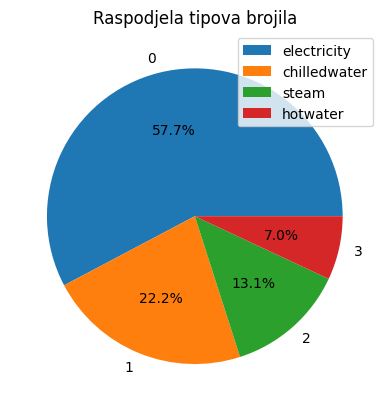

In [27]:
df2.groupby('meter').size()

plt.pie(df2['meter'].value_counts(), labels=df2['meter'].value_counts().index, autopct='%1.1f%%')
plt.title('Raspodjela tipova brojila')
plt.legend(['electricity', 'chilledwater', 'steam', 'hotwater'], loc='upper right')
plt.show()

## 6.3 meter_reading

Varijabla koja pokazuje potrošnju energije.

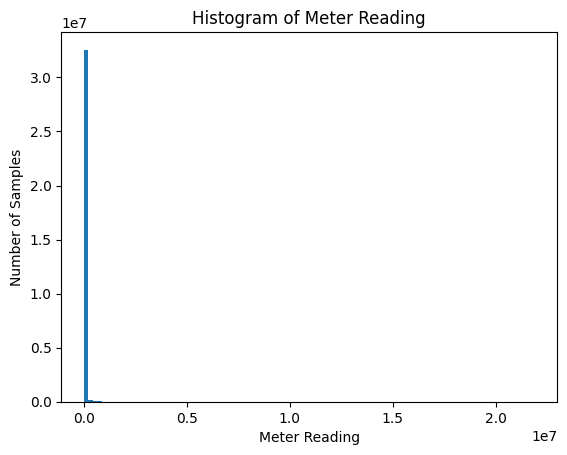

In [28]:
plt.hist(df2['meter_reading'], bins=100)
plt.title('Histogram of Meter Reading')
plt.xlabel('Meter Reading')
plt.ylabel('Number of Samples')
plt.show()

Budući da imamo ogroman raspon vrijednosti, idemo probati vidjeti možemo li dobiti bolji pregled u logaritamskoj skali.

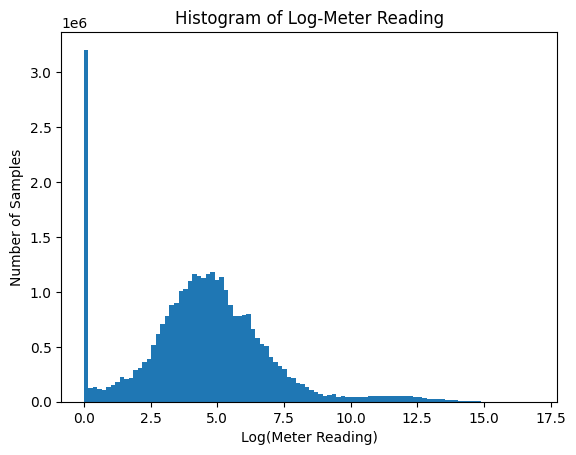

In [29]:
plt.hist(np.log1p(df2['meter_reading']), bins=100)
plt.title('Histogram of Log-Meter Reading')
plt.xlabel('Log(Meter Reading)')
plt.ylabel('Number of Samples')
plt.show()

Izgled grafa je nešto prihvatljiviji, jer u logaritamskoj skali čak i imamo donekle normalnu razdiobu, izuzev velikog broja vrijednosti 0.

## 6.4 primary_use

Kategorička značajka koja nam govori za što se zgrada koristi.

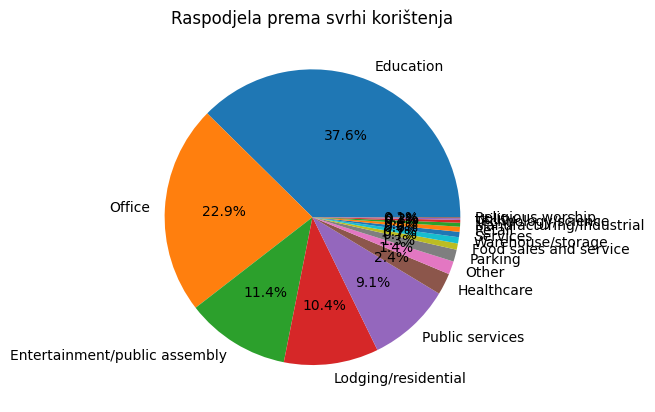

In [30]:
df2.groupby('primary_use').size()

plt.pie(df2['primary_use'].value_counts(), labels=df2['primary_use'].value_counts().index, autopct='%1.1f%%')
plt.title('Raspodjela prema svrhi korištenja')
plt.show()

## 6.5 square_feet

Numerička značajka koja nam govori o veličini zgrade.

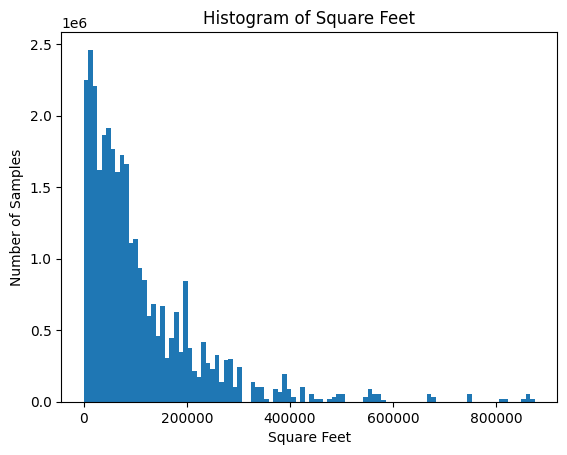

In [31]:
plt.hist(df2['square_feet'], bins=100)
plt.title('Histogram of Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Number of Samples')
plt.show()

## 6.6 air_temperature

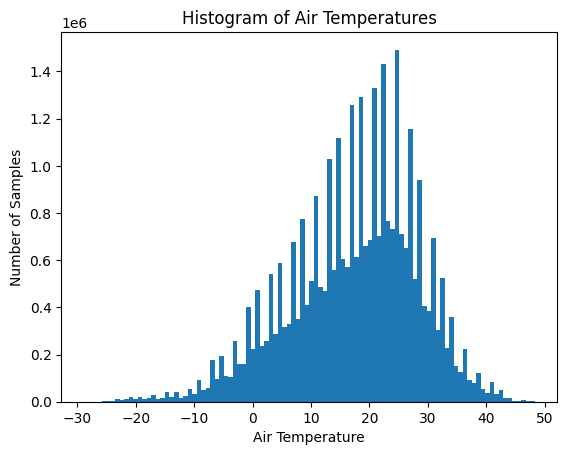

In [32]:
plt.hist(df2['air_temperature'], bins=100)
plt.title('Histogram of Air Temperatures')
plt.xlabel('Air Temperature')
plt.ylabel('Number of Samples')
plt.show()

## 6.7 dew_temperature

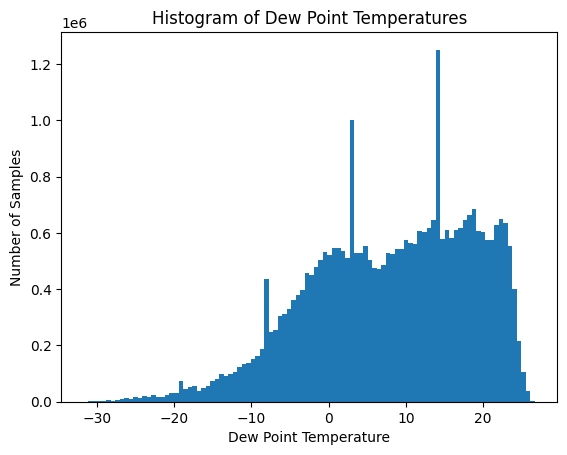

In [33]:
plt.hist(df2['dew_temperature'], bins=100)
plt.title('Histogram of Dew Point Temperatures')
plt.xlabel('Dew Point Temperature')
plt.ylabel('Number of Samples')
plt.show()

## 6.8 precip_depth_1_hr

S obzirom na to da je -1 vrijednost koja označava istu stvar kao i 0 (da nije bilo padalina), zamijenit ćemo sve -1 vrijednosti u precip_depth_1_hr s 0.

In [34]:
df2['precip_depth_1_hr'] = df2['precip_depth_1_hr'].replace(-1, 0)

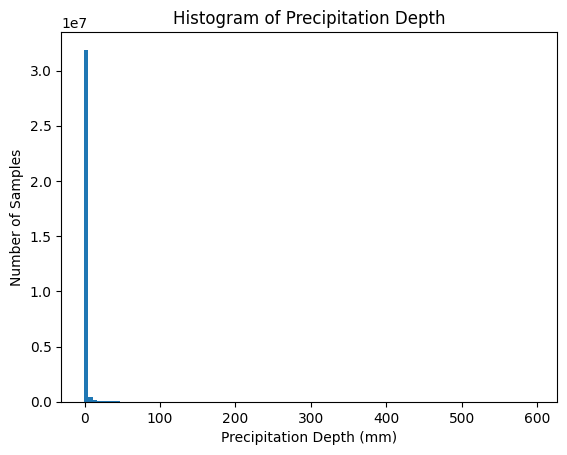

In [35]:
plt.hist(df2['precip_depth_1_hr'], bins=100)
plt.title('Histogram of Precipitation Depth')
plt.xlabel('Precipitation Depth (mm)')
plt.ylabel('Number of Samples')
plt.show()

## 6.9 sea_level_pressure

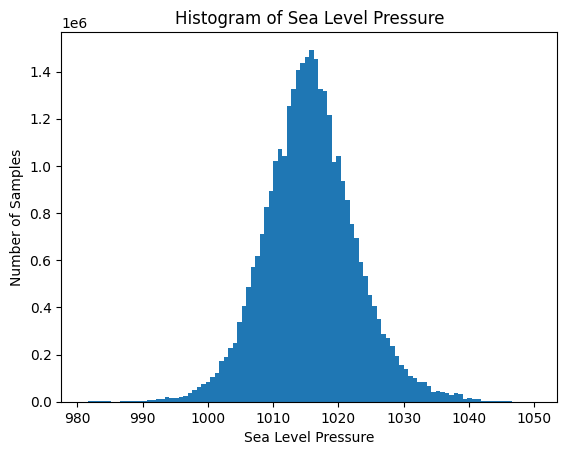

In [36]:
plt.hist(df2['sea_level_pressure'], bins=100)
plt.title('Histogram of Sea Level Pressure')
plt.xlabel('Sea Level Pressure')
plt.ylabel('Number of Samples')
plt.show()

## 6.10 wind_direction

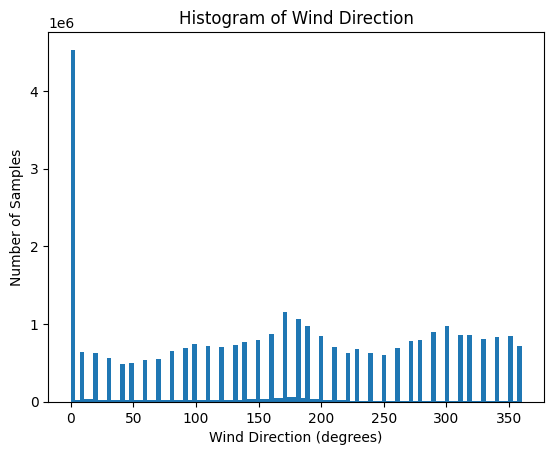

In [37]:
plt.hist(df2['wind_direction'], bins=100)
plt.title('Histogram of Wind Direction')
plt.xlabel('Wind Direction (degrees)')
plt.ylabel('Number of Samples')
plt.show()

## 6.11 wind_speed

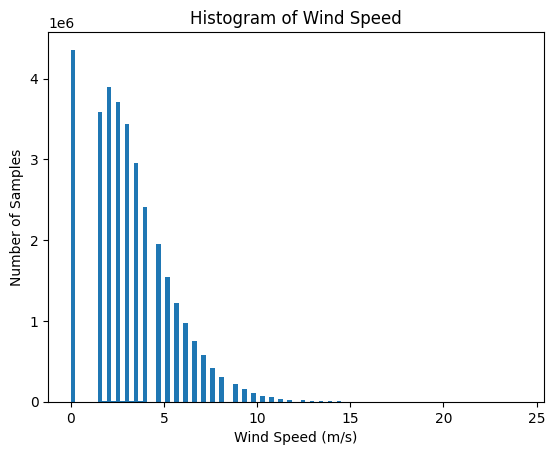

In [38]:
plt.hist(df2['wind_speed'], bins=100)
plt.title('Histogram of Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Number of Samples')
plt.show()

# 7. Vizualizacije

## 7.1 Razdiobe značajke meter_reading po značajki meter (raw + log scale)

Provjerit ćemo kako izgledaju razdiobe značajki meter_reading po značajki meter.

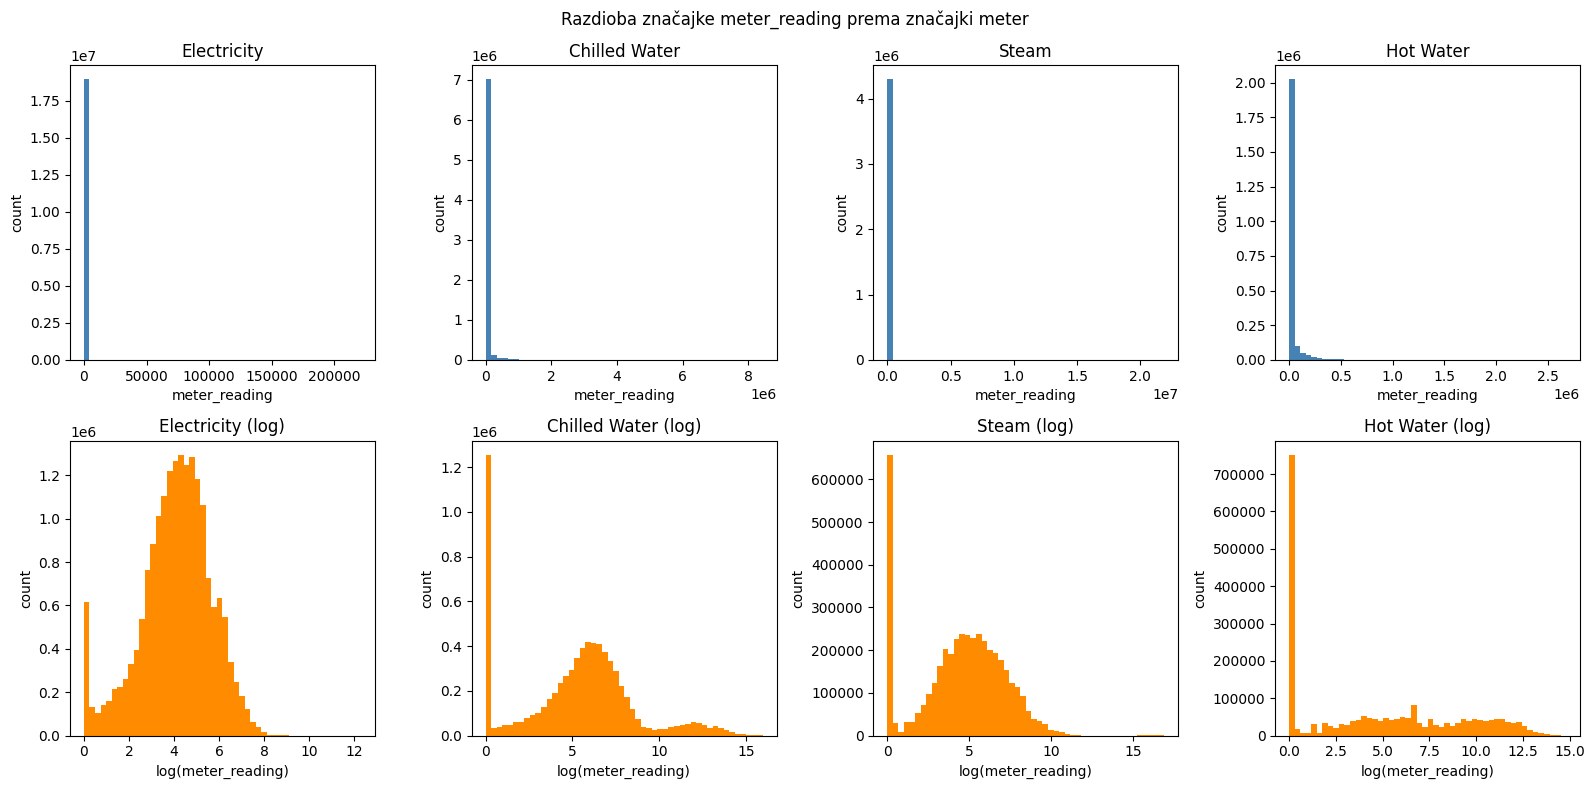

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

meter_labels = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

for meter_id, label in meter_labels.items():
    data = df2[df2['meter'] == meter_id]['meter_reading']

    axes[0, meter_id].hist(data, bins=50, color='steelblue', edgecolor='none')
    axes[0, meter_id].set_title(f'{label}')
    axes[0, meter_id].set_xlabel('meter_reading')
    axes[0, meter_id].set_ylabel('count')

    axes[1, meter_id].hist(np.log1p(data), bins=50, color='darkorange', edgecolor='none')
    axes[1, meter_id].set_title(f'{label} (log)')
    axes[1, meter_id].set_xlabel('log(meter_reading)')
    axes[1, meter_id].set_ylabel('count')

plt.suptitle('Razdioba značajke meter_reading prema značajki meter')
plt.tight_layout()
plt.show()

Sve četiri razdiobe imaju puno vrijednosti 0, što znači je razumljivo jer to znači da je potrošnja nije bila nula. Electricity i Steam se potpuno ravnaju po normalnoj razdiobi, Chilled Water donekle, dok Hot Water više izgleda kao nekakva uniforma razdioba, što nije baš lijepo za vidjeti.

## 7.2 Odnos potrošnje i vremena s obzirom na različite metrike

Sad ćemo pogledati kako su se kretale vrijednosti potrošnje po značajki meter kroz vrijeme.

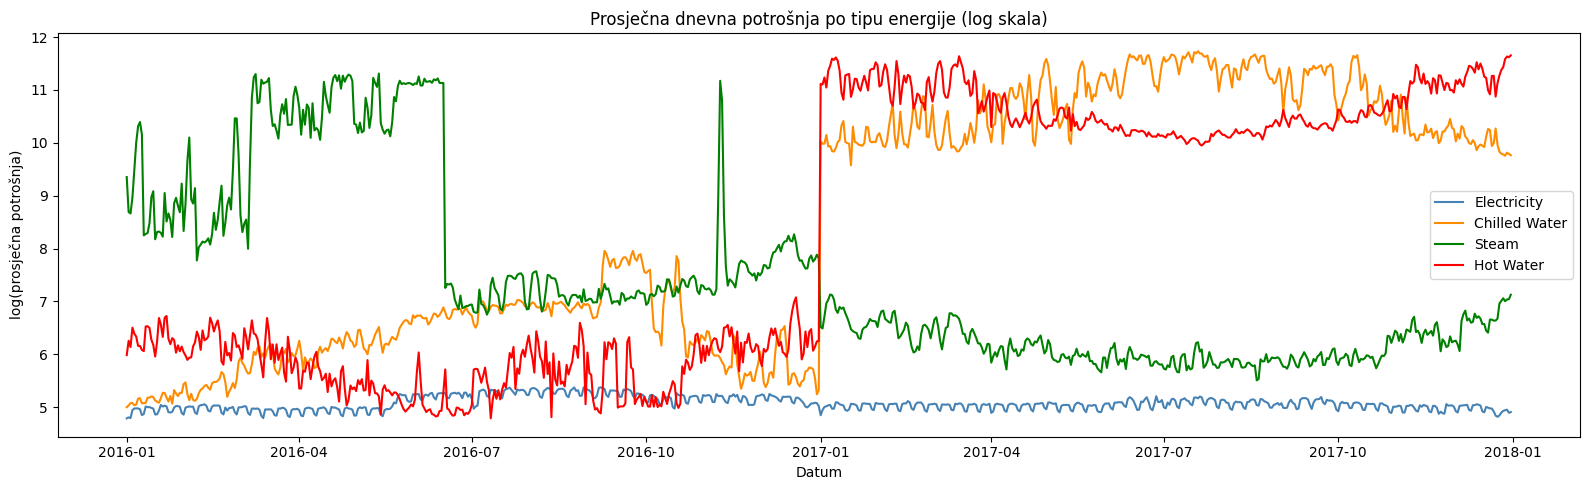

In [40]:
colors = {0: 'steelblue', 1: 'darkorange', 2: 'green', 3: 'red'}

df2['timestamp'] = pd.to_datetime(df2['timestamp'])

fig, ax = plt.subplots(figsize=(16, 5))

for meter_id, label in meter_labels.items():
    daily = df2[df2['meter'] == meter_id].groupby(df2['timestamp'].dt.date)['meter_reading'].mean()  
    ax.plot(list(daily.index), np.log1p(daily.values), color=colors[meter_id], label=label)

ax.set_title('Prosječna dnevna potrošnja po tipu energije (log skala)')
ax.set_xlabel('Datum')
ax.set_ylabel('log(prosječna potrošnja)')
ax.legend()
plt.tight_layout()
plt.show()

Potrošnja gdje je metrika Electricity je gotovo ista čitavo vrijeme, kod Steam je u prvoj polovici 2016. puno veća nego nakon toga, dok Chilled Water i Hot Water imaju čudan porast u 2017. godini.

## 7.3 Odnos potrošnje energije i temperature zraka

Sljedeće što ćemo istražiti je kakav je odnos potrošnje i temperature, i to po svim mjerama.

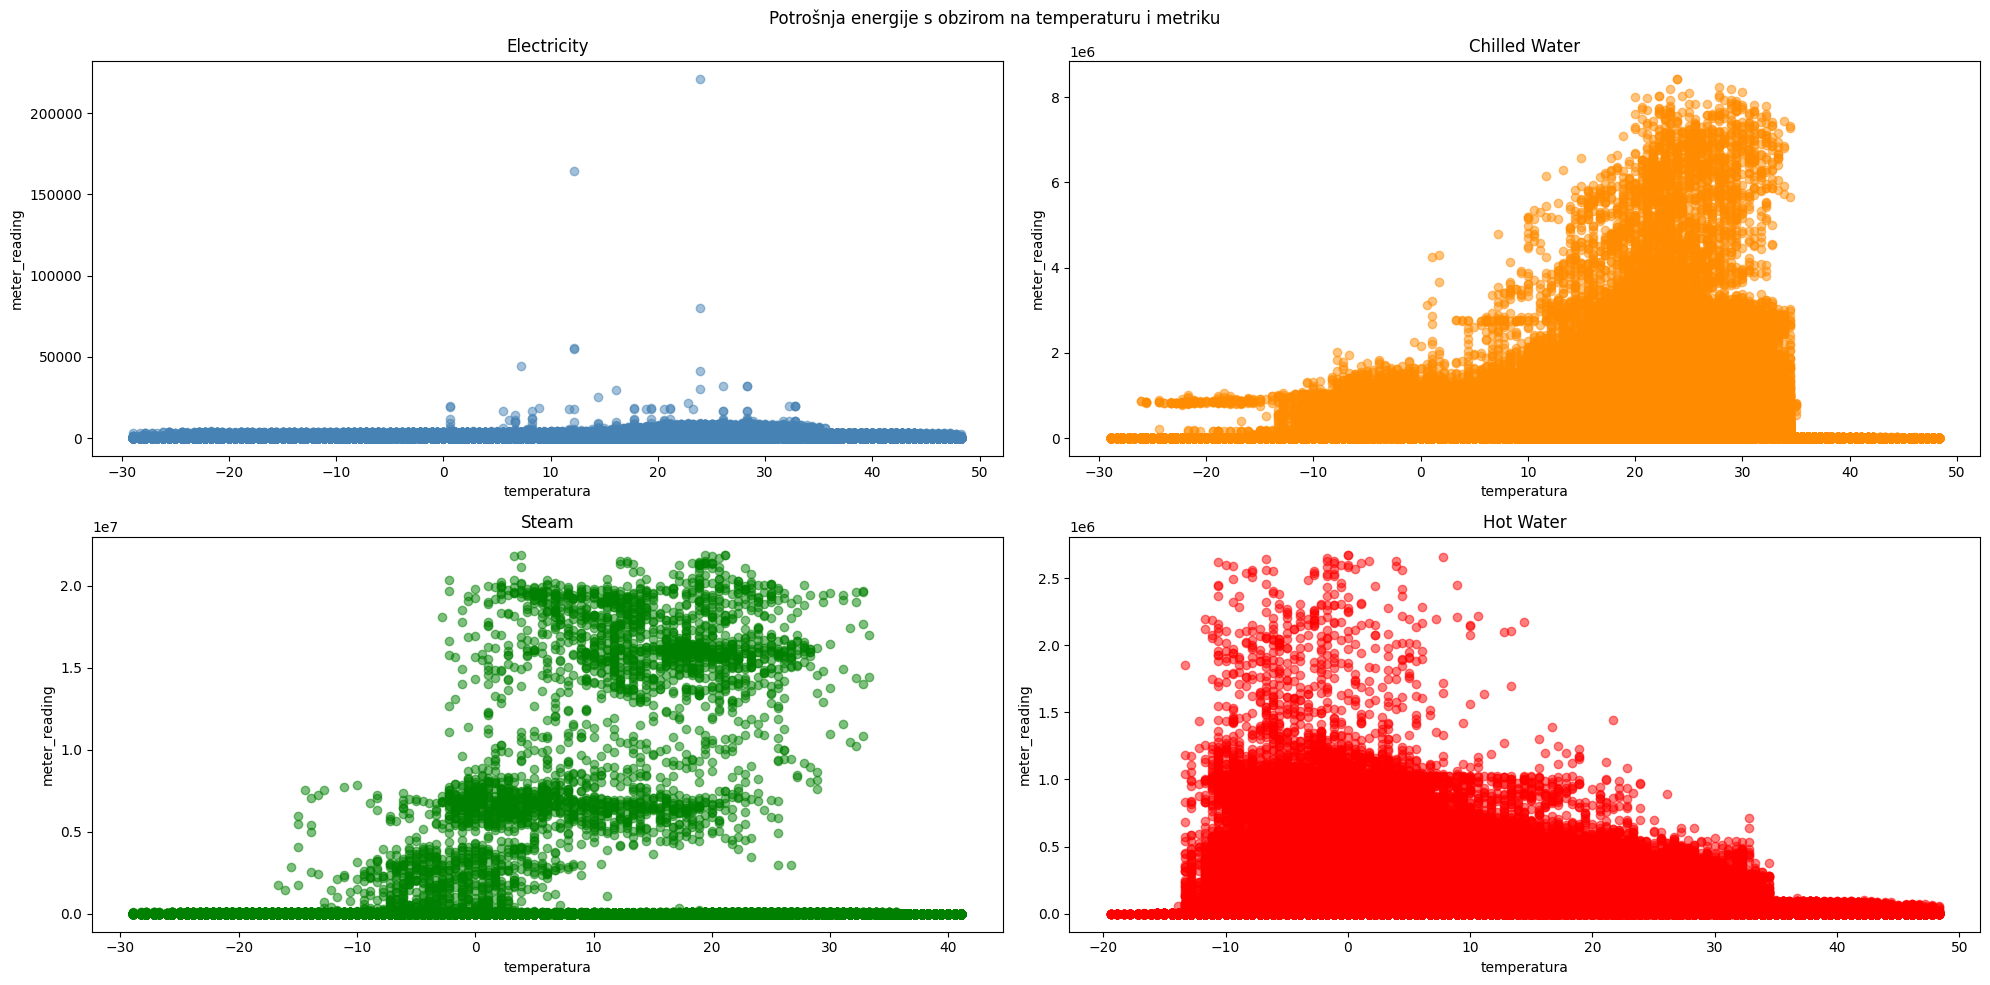

In [41]:

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

for meter_id, label in meter_labels.items():
    data = df2[df2['meter'] == meter_id]
    axes[int(meter_id)//2, int(meter_id)%2].scatter(data['air_temperature'], data['meter_reading'], 
                c=colors[meter_id], label=label, alpha=0.5)
    axes[int(meter_id)//2, int(meter_id)%2].set_title(f'{label}')
    axes[int(meter_id)//2, int(meter_id)%2].set_xlabel('temperatura')
    axes[int(meter_id)//2, int(meter_id)%2].set_ylabel('meter_reading')

plt.suptitle('Potrošnja energije s obzirom na temperaturu i metriku')
plt.tight_layout()
plt.show()

Rezultat je više manje očekivan, naročito za Hot Water i Chilled Water, gdje je u prvom slučaju potrošnja veća na nižim temperaturama, a u drugom veća na višim temperaturama.

## 7.4 Potrošnja energije prema svrhi zgrade

Zatim provjeravamo koje vrste zgrada u prosjeku troše najviše energije. Prvo ćemo vidjeti kakvi tipovi zgrada postoje i koliko ih ima.

In [42]:
df2.groupby('primary_use')['meter_reading'].count()

primary_use
Education                        12363868
Entertainment/public assembly     3747071
Food sales and service             225070
Healthcare                         775298
Lodging/residential               3402298
Manufacturing/industrial           140111
Office                            7520252
Other                              471975
Parking                            431376
Public services                   2996243
Religious worship                   34702
Retail                             182324
Services                           192412
Technology/science                 102608
Utility                             61233
Warehouse/storage                  223854
Name: meter_reading, dtype: int64

Za detaljnije promatranje odabrat ćemo 5 tipova zgrada koje imaju preko milijun uzoraka, a to su Education, Entertainment/public assembly, Lodging/residential, Office i Public services.

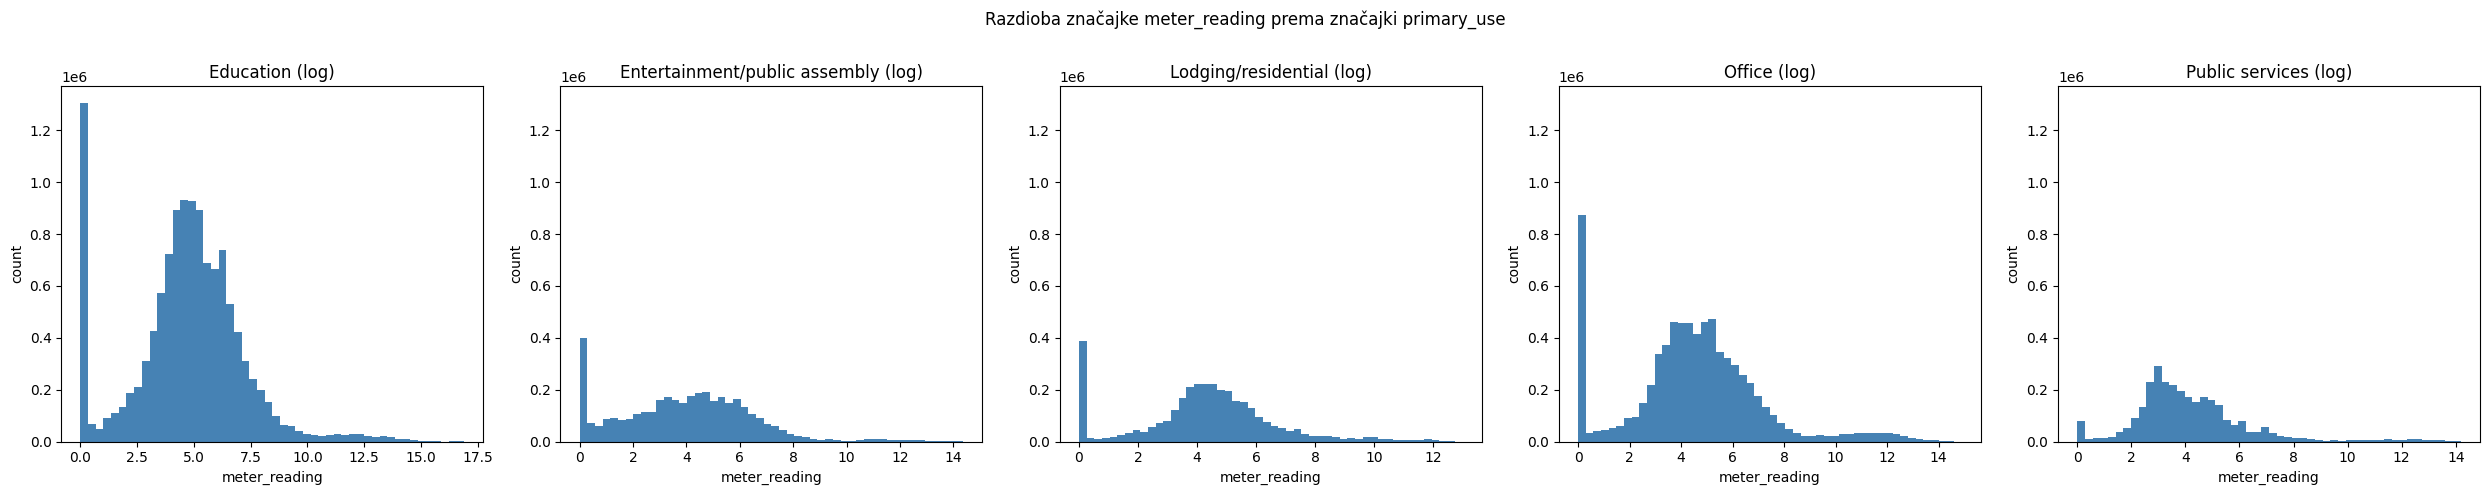

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

primary_use_labels = {'Education': 0, 'Entertainment/public assembly': 1, 'Lodging/residential': 2, 'Office': 3, 'Public services': 4}

for primary_use, ind in primary_use_labels.items():
    data = df2[df2['primary_use'] == primary_use]['meter_reading']

    axes[ind].hist(np.log1p(data), bins=50, color='steelblue', edgecolor='none')
    axes[ind].set_title(f'{primary_use} (log)')
    axes[ind].set_xlabel('meter_reading')
    axes[ind].set_ylabel('count')

ylim = max(ax.get_ylim()[1] for ax in axes)

for ax in axes:
    ax.set_ylim(0, ylim)

plt.suptitle('Razdioba značajke meter_reading prema značajki primary_use')
plt.tight_layout()
plt.show()

Najveću potrošnju od izabranih tipova zgrada imaju edukacijske zgrade i uredi.

## 7.5 Usporedba potrošnje po danu i noći

Promatrat ćemo kakav je odnos potrošnje struje po danu i po noći. Zbog velikih raspona vrijednosti i preglednosti, vrijednosti meter_reading bit će prikazani u logaritamskoj skali.

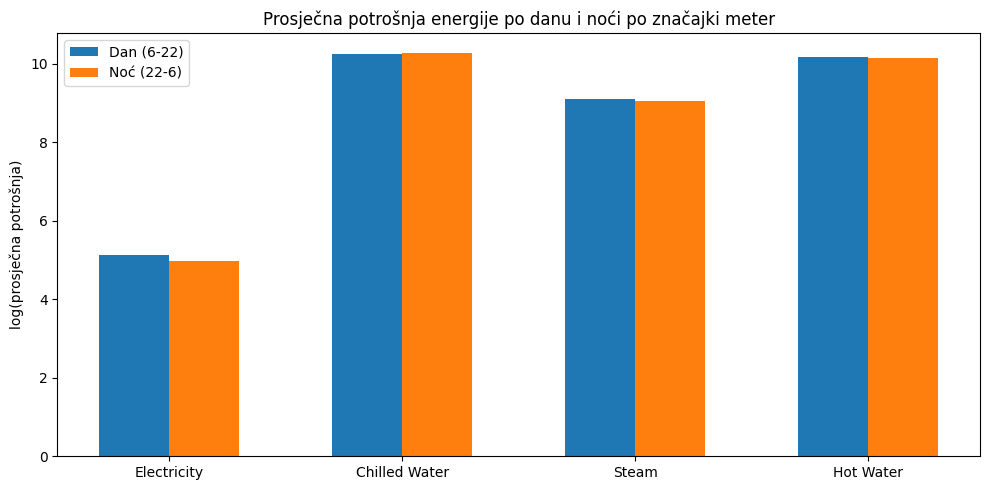

In [44]:
df2['hour'] = df2['timestamp'].dt.hour
df2['period'] = df2['hour'].apply(lambda x: 'Dan (6-22)' if 6 <= x < 22 else 'Noć (22-6)')

dan_noc = df2.groupby(['period', 'meter'])['meter_reading'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(meter_labels))
width = 0.3

dan = dan_noc[dan_noc['period'] == 'Dan (6-22)']
noc = dan_noc[dan_noc['period'] == 'Noć (22-6)']

bars1 = ax.bar(x - width/2, np.log1p(dan['meter_reading']), width, label='Dan (6-22)')
bars2 = ax.bar(x + width/2, np.log1p(noc['meter_reading']), width, label='Noć (22-6)')

ax.set_xticks(x)
ax.set_xticklabels(meter_labels.values())
ax.set_ylabel('log(prosječna potrošnja)')
ax.set_title('Prosječna potrošnja energije po danu i noći po značajki meter')
ax.legend()
plt.tight_layout()
plt.show()

Kao što je i bilo za očekivati, ukupna nešto veća potrošnja struje je po danu nego po noći, iako razlika nije toliko velika.

## 7.6 Usporedba potrošnje radnim danom i vikendom

Slična usporedba, samo ovaj puta gledamo radni dan i vikend. Vrijednosti meter_reading su i dalje u logaritamskoj skali.

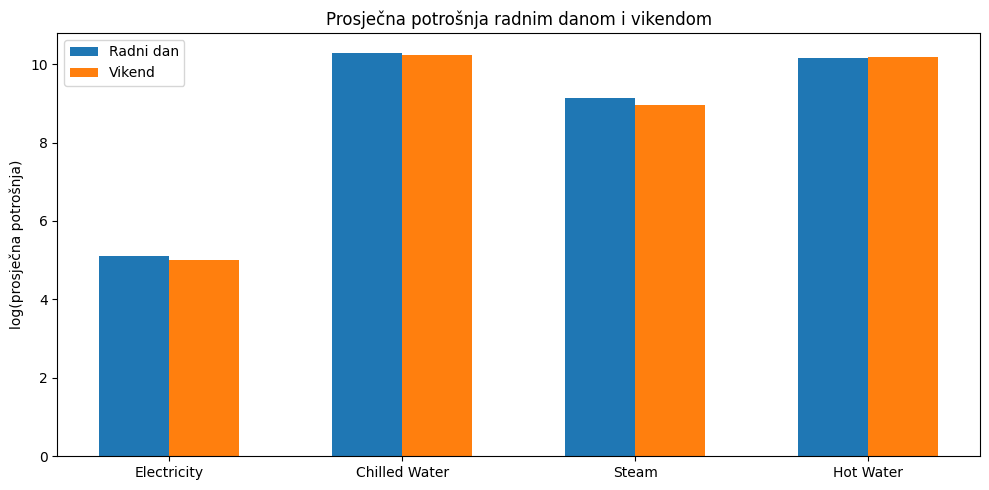

In [45]:
df2['day_of_week'] = df2['timestamp'].dt.dayofweek
df2['is_weekend'] = df2['day_of_week'].apply(lambda x: 'Vikend' if x >= 5 else 'Radni dan')

weekend = df2.groupby(['is_weekend', 'meter'])['meter_reading'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(meter_labels))
width = 0.3

radni = weekend[weekend['is_weekend'] == 'Radni dan']
vikend = weekend[weekend['is_weekend'] == 'Vikend']

ax.bar(x - width/2, np.log1p(radni['meter_reading']), width, label='Radni dan')
ax.bar(x + width/2, np.log1p(vikend['meter_reading']), width, label='Vikend')

ax.set_xticks(x)
ax.set_xticklabels(meter_labels.values())
ax.set_ylabel('log(prosječna potrošnja)')
ax.set_title('Prosječna potrošnja radnim danom i vikendom')
ax.legend()
plt.tight_layout()
plt.show()

Kao i za dan/noć, razlike nisu velike, ali opet je potrošnja nešto veća tijekom radnih dana. Malo ćemo detaljnije promotriti kako se kreće potrošnja ako još uključimo pojedine tipove zgrada.

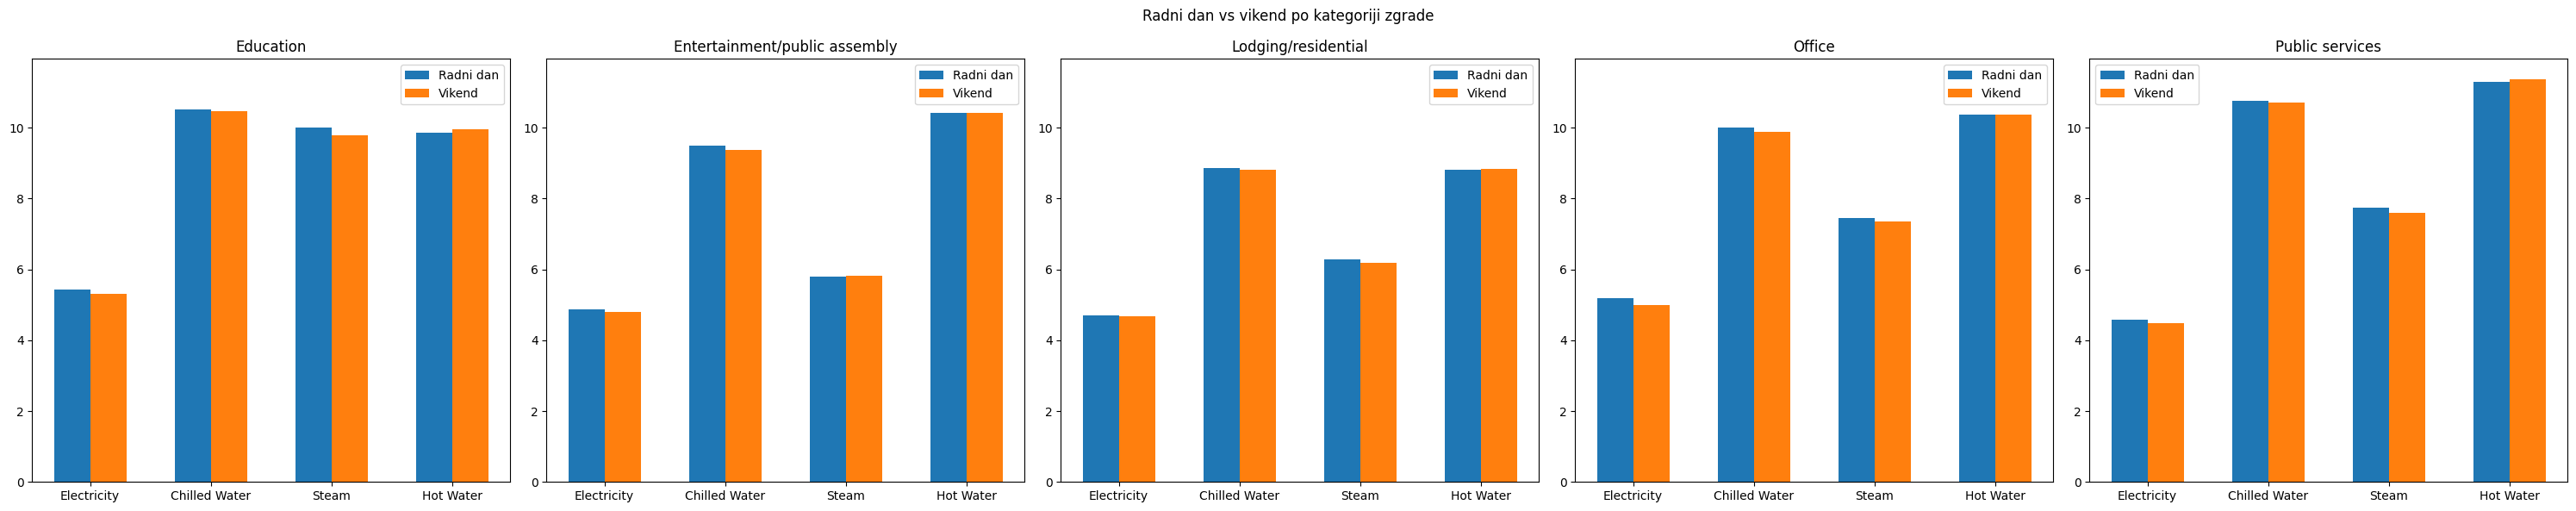

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
axes = axes.flatten()

for primary_use, ind in primary_use_labels.items():
    data = df2[df2['primary_use'] == primary_use].groupby(['is_weekend', 'meter'])['meter_reading'].mean().reset_index()
    
    radni = data[data['is_weekend'] == 'Radni dan']
    vikend = data[data['is_weekend'] == 'Vikend']
    
    x = np.arange(4)
    width = 0.3
    axes[ind].bar(x - width/2, np.log1p(radni['meter_reading']), width, label='Radni dan')
    axes[ind].bar(x + width/2, np.log1p(vikend['meter_reading']), width, label='Vikend')
    axes[ind].set_title(primary_use)
    axes[ind].set_xticks(x)
    axes[ind].set_xticklabels(meter_labels.values())
    axes[ind].legend()

ylim = max(ax.get_ylim()[1] for ax in axes)

for ax in axes:
    ax.set_ylim(0, ylim)

plt.suptitle('Radni dan vs vikend po kategoriji zgrade')
plt.tight_layout()
plt.show()

Zaključak ostaje isti, potrošnja se ne razlikuje pretjerano po različitim tipovima zgrada, u svakoj zgradi je u prosjeku potrošnja malo veća tijekom radnog dana nego tijekom vikenda.

# 8. Potrošnja energije u 2016.

Posljednji zadatak je odrediti tijekom kojeg dana u 2016. godini jest potrošnja bila najveća i pokušati odrediti razlog toga.

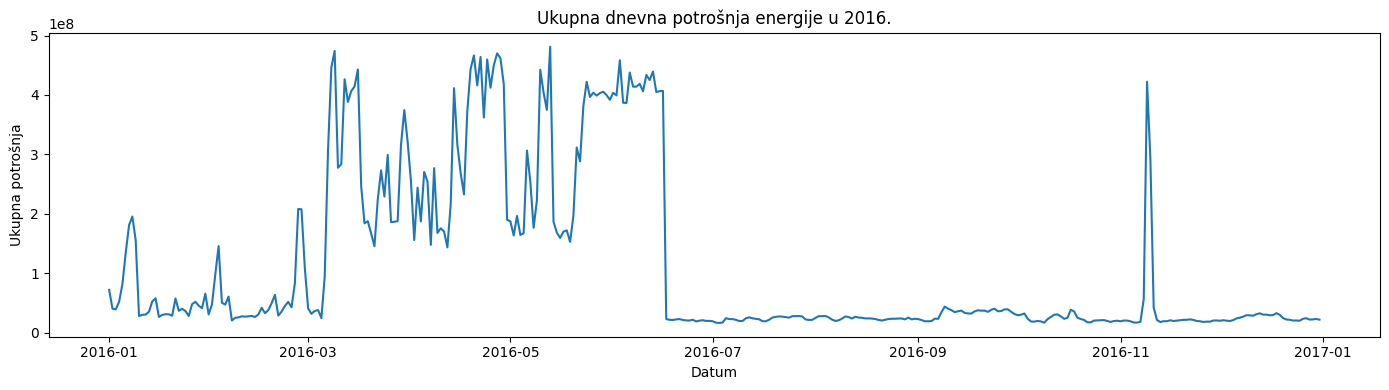

In [47]:
df_2016 = df2[df2['timestamp'].dt.year == 2016]

daily = df_2016.groupby(df2['timestamp'].dt.date)['meter_reading'].sum().sort_values(ascending=False)

daily_sorted = df_2016.groupby(df2['timestamp'].dt.date)['meter_reading'].sum()
plt.figure(figsize=(14, 4))
plt.plot(list(daily_sorted.index), daily_sorted.values)
plt.title('Ukupna dnevna potrošnja energije u 2016.')
plt.xlabel('Datum')
plt.ylabel('Ukupna potrošnja')
plt.tight_layout()
plt.show()

In [48]:
best_day = daily.index[0]
print(f"\nNajveća potrošnja: {best_day}")

weather_best_day = df2[df2['timestamp'].dt.date == best_day][
    ['air_temperature', 'dew_temperature', 'wind_speed', 'precip_depth_1_hr']
].mean()
print("\nVrijeme tog dana:")
print(weather_best_day.round(2))

building_consumption = df2[df2['timestamp'].dt.date == best_day].groupby('primary_use')['meter_reading'].sum().sort_values(ascending=False)
print("\nPotrošnja po kategoriji zgrada:")
print(building_consumption)

meter_consumption = df2[df2['timestamp'].dt.date == best_day].groupby('meter')['meter_reading'].sum()
print("\nPotrošnja po tipu metra:")
print(meter_consumption.rename(index=meter_labels))


Najveća potrošnja: 2016-05-13

Vrijeme tog dana:
air_temperature      20.49
dew_temperature      10.74
wind_speed            3.18
precip_depth_1_hr     0.49
dtype: float64

Potrošnja po kategoriji zgrada:
primary_use
Education                        4.691799e+08
Office                           5.547251e+06
Services                         2.113866e+06
Entertainment/public assembly    1.163498e+06
Public services                  1.138548e+06
Lodging/residential              1.081174e+06
Healthcare                       7.332907e+05
Other                            8.941130e+04
Food sales and service           8.431193e+04
Manufacturing/industrial         6.491105e+04
Utility                          5.155033e+04
Parking                          4.028849e+04
Warehouse/storage                1.306194e+04
Technology/science               8.103919e+03
Retail                           6.903412e+03
Religious worship                1.255700e+02
Name: meter_reading, dtype: float64

Potrošnja

Iz gore dobivenih podataka ne možemo jasno zaključiti zašto je taj dan potrošnja bila najveća. Morat ćemo to još malo detaljnije istražiti. Pogledat ćemo kako se potrošnja kretala po svakom siteu zasebno.

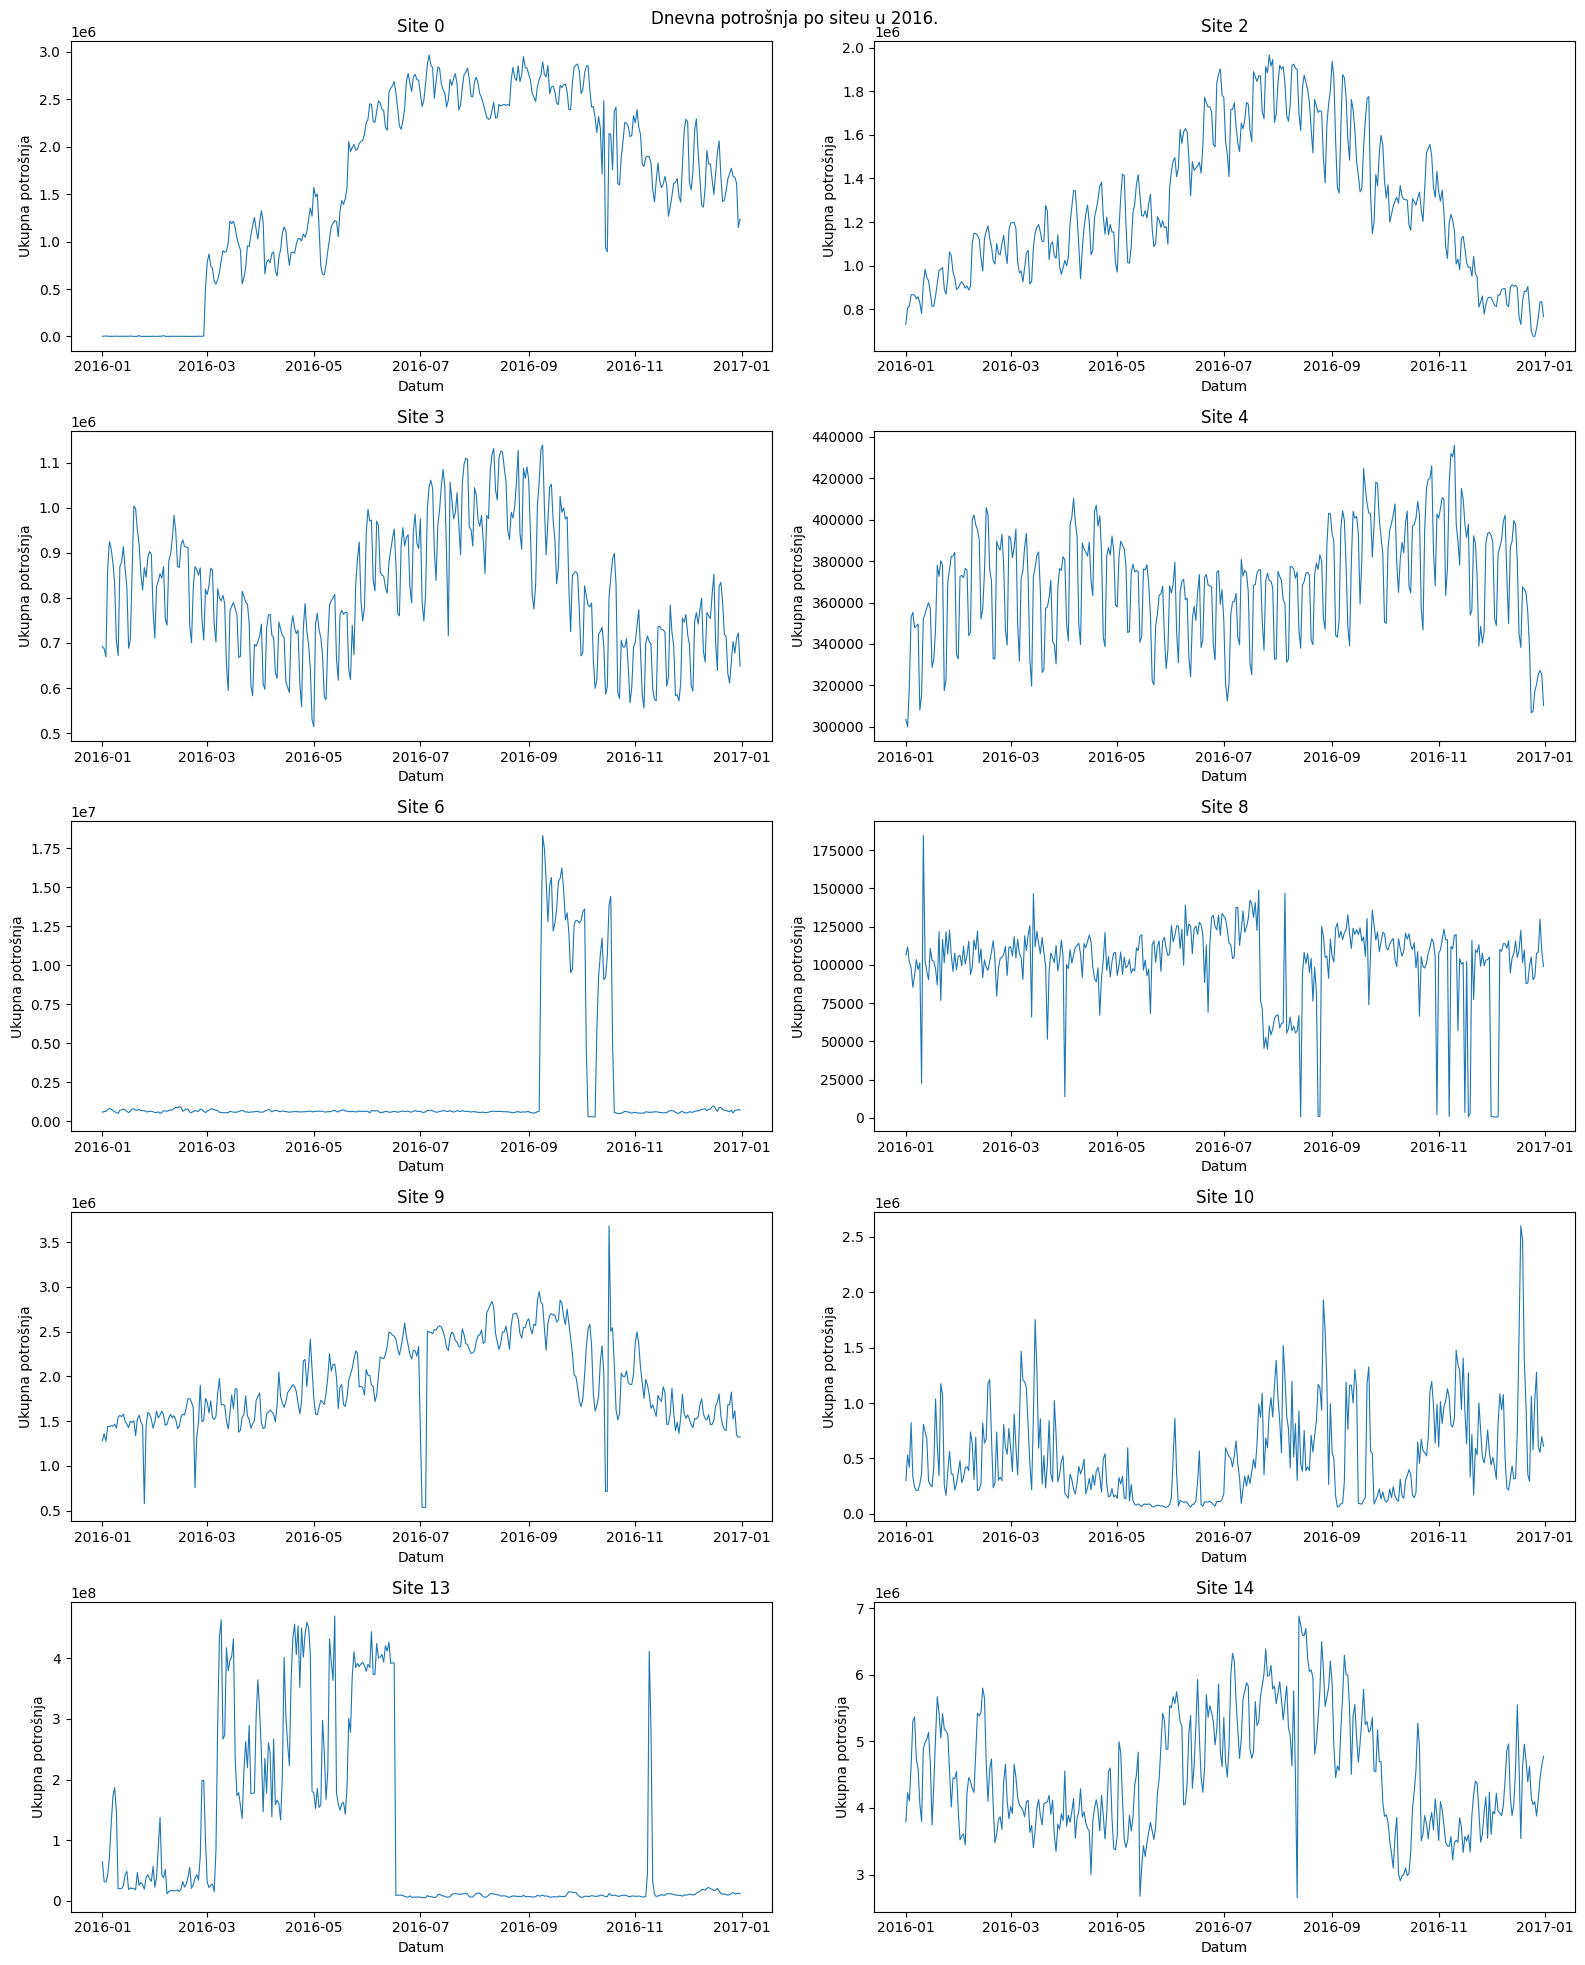

In [49]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

sites = sorted(df2['site_id'].unique())

for i, site in enumerate(sites):
    df_site = df2[(df2['site_id'] == site) & (df2['timestamp'].dt.year == 2016)]
    daily = df_site.groupby(df2['timestamp'].dt.date)['meter_reading'].sum()
    
    axes[i].plot(list(daily.index), daily.values, linewidth=0.8)
    axes[i].set_title(f'Site {site}')
    axes[i].set_xlabel('Datum')
    axes[i].set_ylabel('Ukupna potrošnja')
    axes[i].tick_params(axis='x')

plt.suptitle('Dnevna potrošnja po siteu u 2016.')
plt.tight_layout()
plt.show()

Razlog što je potrošnja bila najveća dana 13.5.2016. je site 13. Sad treba provjeriti što se događalo tamo tog dana i zatim pokušati naći razlog za toliku potrošnju.

In [50]:
weather_best_day = df2[(df2['timestamp'].dt.date == best_day) & (df2['site_id'] == 13)][
    ['air_temperature', 'dew_temperature', 'wind_speed', 'precip_depth_1_hr']
].mean()
print("\nVrijeme na siteu 13:")
print(weather_best_day.round(2))

building_consumption = df2[(df2['timestamp'].dt.date == best_day) & (df2['site_id'] == 13)].groupby('primary_use')['meter_reading'].sum().sort_values(ascending=False)
print("\nPotrošnja po kategoriji zgrada na siteu 13:")
print(building_consumption)

meter_consumption = df2[(df2['timestamp'].dt.date == best_day) & (df2['site_id'] == 13)].groupby('meter')['meter_reading'].sum()
print("\nPotrošnja po tipu metra na siteu 13:")
print(meter_consumption.rename(index=meter_labels))


Vrijeme na siteu 13:
air_temperature      8.35
dew_temperature      3.12
wind_speed           5.42
precip_depth_1_hr    1.88
dtype: float64

Potrošnja po kategoriji zgrada na siteu 13:
primary_use
Education                        4.626726e+08
Office                           3.737456e+06
Services                         2.101430e+06
Public services                  5.101275e+05
Lodging/residential              2.116336e+05
Entertainment/public assembly    1.811727e+05
Healthcare                       9.080888e+04
Manufacturing/industrial         6.491105e+04
Parking                          3.392534e+04
Other                            1.459285e+04
Food sales and service           5.470272e+03
Technology/science               3.329000e+03
Warehouse/storage                1.173007e+03
Name: meter_reading, dtype: float64

Potrošnja po tipu metra na siteu 13:
meter
Electricity      7.255790e+05
Chilled Water    1.288615e+05
Steam            4.687742e+08
Name: meter_reading, dtype: float6

Djeluje da je to bio jedan malo hladniji dan u petom mjesecu, budući da je prosječna temperatura bila manja od 10 stupnjeva i da se zbog toga potrošilo više energije za grijanje. Naravno, postoji određeni skepticizam u vezi točnosti potrošnje energije jer zimski dani mogu biti još dosta hladniji od toga. Općenito, podaci za taj site djeluju sumnjivo zato što potrošnja energije višestruko pada u drugoj polovici 2016. godine, ali zasad ih ostavljam u skupu podataka.